## Exercise 3

### Part 1

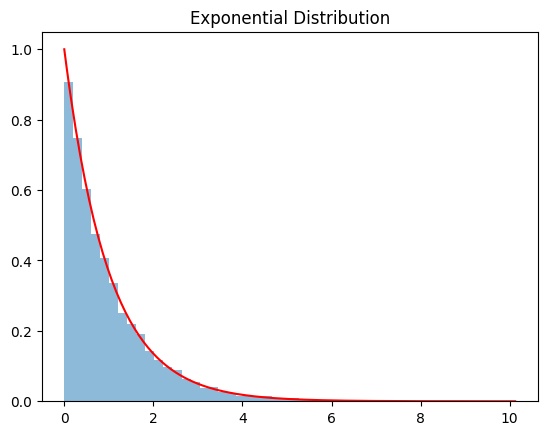

KS test exponential: KstestResult(statistic=0.0052641007287348995, pvalue=0.9431157988493369, statistic_location=0.6698915008804583, statistic_sign=1)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

N = 10000

# Exponential distribution
Lam = 1.0

u = np.random.uniform(0, 1, N)
exp_data = -np.log(1 - u) / Lam

x = np.linspace(0, np.max(exp_data), 200)
pdf = Lam * np.exp(-Lam * x)

plt.hist(exp_data, bins=50, density=True, alpha=0.5)
plt.plot(x, pdf, 'r')
plt.title("Exponential Distribution")
plt.show()

print("KS test exponential:", stats.kstest(exp_data, 'expon', args=(0, 1/Lam)))

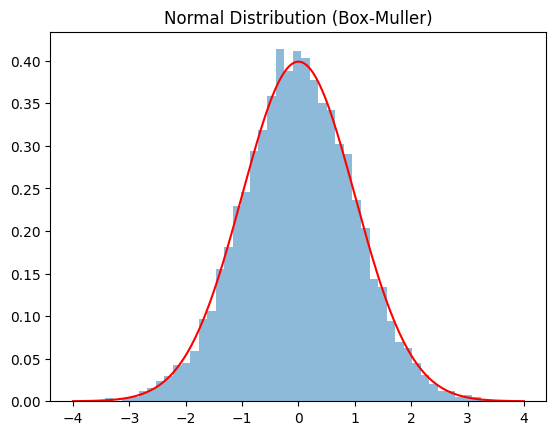

KS test normal: KstestResult(statistic=0.0076056093997897145, pvalue=0.6066373836398911, statistic_location=-0.45791818878901136, statistic_sign=-1)


In [8]:
# Normal distribution (box-muller)
u1 = np.random.uniform(0, 1, N)
u2 = np.random.uniform(0, 1, N)

z = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)

x = np.linspace(-4, 4, 200)
pdf = stats.norm.pdf(x, 0, 1)

plt.hist(z, bins=50, density=True, alpha=0.5)
plt.plot(x, pdf, 'r')
plt.title("Normal Distribution (Box-Muller)")
plt.show()

print("KS test normal:", stats.kstest(z, 'norm'))

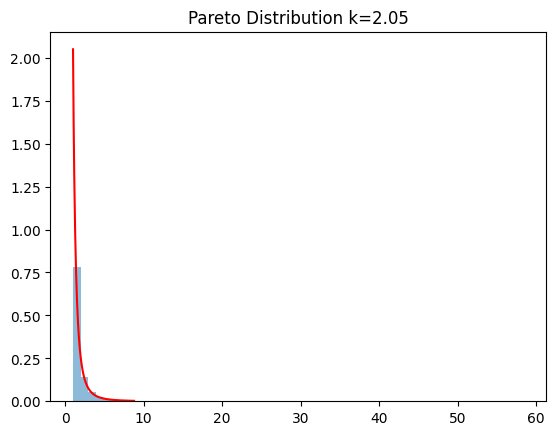

KS test Pareto k=2.05: KstestResult(statistic=0.009465005773743845, pvalue=0.3297445993654793, statistic_location=1.047099508050177, statistic_sign=1)


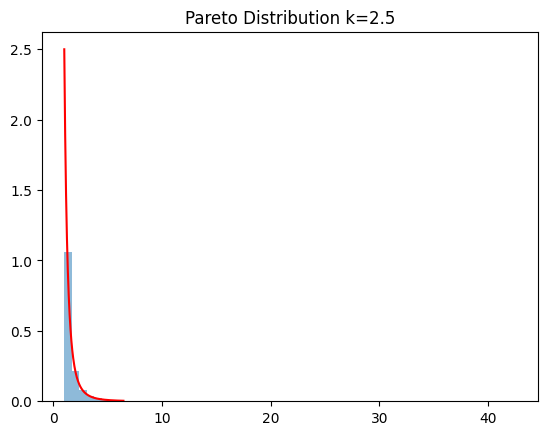

KS test Pareto k=2.5: KstestResult(statistic=0.011080106088292963, pvalue=0.17029119893573652, statistic_location=1.1327989301041264, statistic_sign=1)


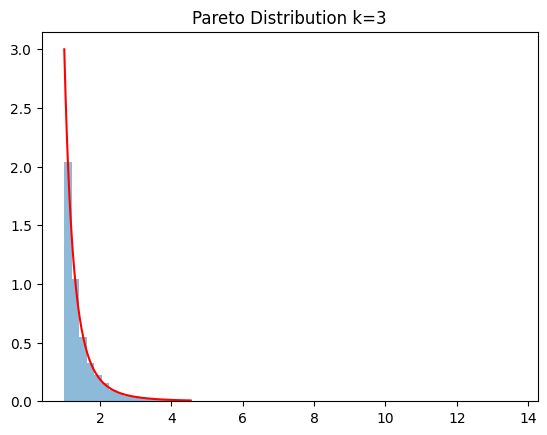

KS test Pareto k=3: KstestResult(statistic=0.011609238278093958, pvalue=0.13393481875685243, statistic_location=1.2481413146057478, statistic_sign=-1)


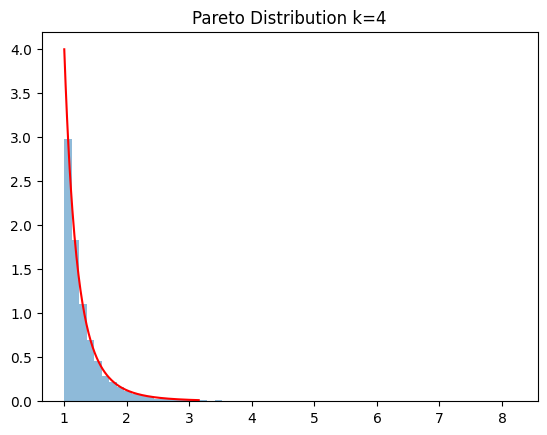

KS test Pareto k=4: KstestResult(statistic=0.010234646164846706, pvalue=0.24402976226141093, statistic_location=1.1073474731343813, statistic_sign=-1)


In [9]:
# Pareto distribution
beta = 1

for k in [2.05, 2.5, 3, 4]:
    u = np.random.uniform(0, 1, N)
    pareto = beta * (1 - u) ** (-1 / k)

    x = np.linspace(beta, np.percentile(pareto, 99), 200)
    pdf = (k * beta**k) / (x**(k + 1))

    plt.hist(pareto, bins=60, density=True, alpha=0.5)
    plt.plot(x, pdf, 'r')
    plt.title(f"Pareto Distribution k={k}")
    plt.show()

    print(f"KS test Pareto k={k}:", stats.kstest(pareto, 'pareto', args=(k,)))

### Part 2

In [ ]:
# Set parameters
beta = 1
N = 100000

for k in [2.05, 2.5, 3, 4]:

    u = np.random.uniform(0, 1, N)
    pareto = beta * (1 - u)**(-1/k)

    sample_mean = np.mean(pareto)
    sample_var = np.var(pareto, ddof=1)

    theoretical_mean = beta * k / (k - 1)

    theoretical_var = beta**2 * k / ((k - 1)**2 * (k - 2))

    print(f"\nk = {k}")
    print(f"Sample mean      = {sample_mean:.4f}")
    print(f"Theoretical mean = {theoretical_mean:.4f}")

    print(f"Sample variance      = {sample_var:.4f}")
    print(f"Theoretical variance = {theoretical_var:.4f}")


k = 2.05
Sample mean      = 1.9475
Theoretical mean = 1.9524
Sample variance      = 6.1028
Theoretical variance = 37.1882

k = 2.5
Sample mean      = 1.6644
Theoretical mean = 1.6667
Sample variance      = 1.7287
Theoretical variance = 2.2222

k = 3
Sample mean      = 1.4998
Theoretical mean = 1.5000
Sample variance      = 0.7328
Theoretical variance = 0.7500

k = 4
Sample mean      = 1.3352
Theoretical mean = 1.3333
Sample variance      = 0.2446
Theoretical variance = 0.2222


The simulated means are all pretty close to the theoretical means for all values of k. The variance values were also close expect for k=2.05, which is due to the Paleto distribution being very heavy-tailed when k is close to 2.

### Part 3

In [ ]:
# Set parameters
n = 10
num_intervals = 100

# Counters
mean_contains = 0
var_contains = 0

for i in range(num_intervals):

    # Box–Muller (normal sample)
    u1 = np.random.uniform(0, 1, n)
    u2 = np.random.uniform(0, 1, n)

    x = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)

    # Sample statistics
    mean = np.mean(x)
    s2 = np.var(x, ddof=1)

    # CI for mean
    tcrit = stats.t.ppf(0.975, n - 1)

    mean_lower = mean - tcrit * np.sqrt(s2) / np.sqrt(n)
    mean_upper = mean + tcrit * np.sqrt(s2) / np.sqrt(n)

    if mean_lower <= 0 <= mean_upper:
        mean_contains += 1

    # CI for variance
    chi2_lower = stats.chi2.ppf(0.025, n - 1)
    chi2_upper = stats.chi2.ppf(0.975, n - 1)

    var_lower = (n - 1) * s2 / chi2_upper
    var_upper = (n - 1) * s2 / chi2_lower

    if var_lower <= 1 <= var_upper:
        var_contains += 1


print("Mean intervals containing true mean:")
print(mean_contains, "out of", num_intervals)

print("\nVariance intervals containing true variance:")
print(var_contains, "out of", num_intervals)

Mean intervals containing true mean:
92 out of 100

Variance intervals containing true variance:
97 out of 100


Out of the 100 generated 95% confidence intervals, 92 intervals for the mean and 97 intervals for the variance contained the true values. This varies a little for each run of the code, but both results are reasonably close to the theoretical values, and therefore indicate that the confidence intervals perform as expected.

### Part 4

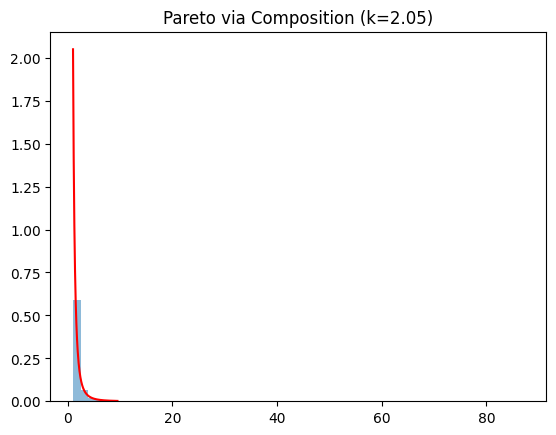

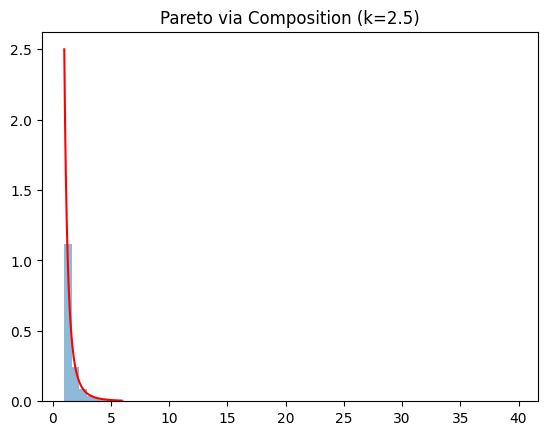

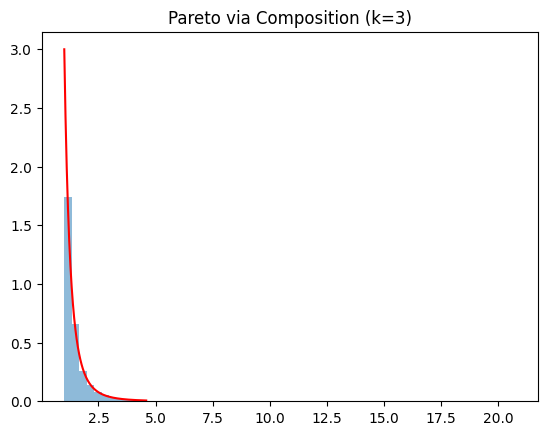

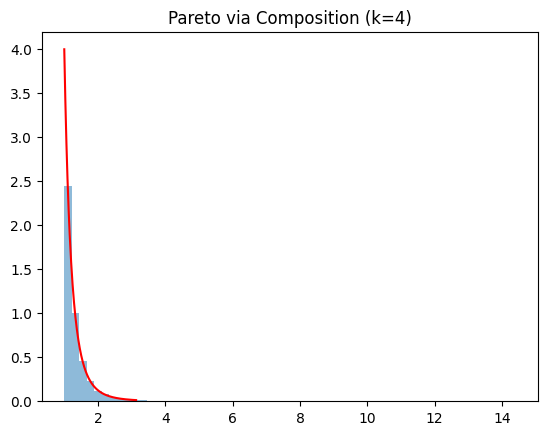

In [ ]:
# Set parameters
N = 10000
beta = 1

for k in [2.05, 2.5, 3, 4]:

    # Exponential variable (composition step)
    y = np.random.exponential(scale=1/k, size=N)

    # Transform to Pareto
    x = beta * np.exp(y)

    # Plot
    plt.hist(x, bins=60, density=True, alpha=0.5)

    t = np.linspace(beta, np.percentile(x, 99), 200)
    pdf = (k * beta**k) / (t**(k + 1))
    plt.plot(t, pdf, 'r')

    plt.title(f"Pareto via Composition (k={k})")
    plt.show()